<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/reservoirsimulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dry-gas reservoir depletion and reinjection with NeqSim

**Audience:** reservoir, production, and facilities engineers learning compositional tank models.

**Prerequisites:** basic Python, gas PVT concepts, absolute pressure, standard gas volume, and
material balance.

## Learning objectives

After completing this notebook you can:

- build a reproducible Peng-Robinson reservoir gas;
- initialize NeqSim's `SimpleReservoir` with a fixed pore volume;
- attach producer and injector streams and advance time explicitly;
- validate pressure decline with the dry-gas $p/z$ material-balance line;
- close standard-volume and component-mole balances;
- compare production-rate and gas-reinjection scenarios; and
- recognize when a zero-dimensional tank model is not suitable.

In [1]:
import importlib.util
import subprocess
import sys


running_in_colab = "google.colab" in sys.modules
neqsim_missing = importlib.util.find_spec("neqsim") is None

if running_in_colab or neqsim_missing:
    install_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-cache-dir",
        "--quiet",
        "neqsim",
    ]
    subprocess.run(install_command, check=True)

print("NeqSim is available in this runtime.")

NeqSim is available in this runtime.


## 1. Engineering context

A material-balance or tank model represents the reservoir as one well-mixed thermodynamic
volume. It is useful for rapid depletion forecasts, scenario screening, and checking a more
detailed reservoir model. It does not resolve wells, grid blocks, permeability, saturation
fronts, pressure gradients, coning, or aquifer geometry.

The worked case is a synthetic dry-gas accumulation at 100°C and 250 bara. It has a fixed
20 million m³ pore volume, produces at a constant standard-gas rate, and has no aquifer. A
second case reinjects 40% of the nominal gas rate. These are deterministic teaching inputs,
not field data or a reserves estimate.

In [2]:
import math
import platform
import subprocess
from importlib.metadata import version

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


SECONDS_PER_DAY = 86_400.0
DAYS_PER_YEAR = 365.25
JavaUUID = jpype.JClass("java.util.UUID")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

neqsim_version = version("neqsim")
python_version = platform.python_version()
java_result = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
)
java_version = (java_result.stderr or java_result.stdout).splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [neqsim_version, python_version, java_version],
    }
)
display(runtime_table)

  Runtime                               Version
0  NeqSim                                3.16.0
1  Python                               3.12.13
2    Java  openjdk version "17.0.19" 2026-04-21


## 2. Assumptions, basis, and units

The model is isothermal at 373.15 K and has a fixed bulk fluid volume. Pressure is absolute and
reported in bara. Rates are standard cubic metres per day at NeqSim's standard reference state;
inventory is reported in Sm³ or GSm³. Time steps are seconds internally and years in tables.

Assumptions are: one homogeneous gas phase, instantaneous thermodynamic equilibrium, no rock or
connate-water compressibility, no aquifer influx, no heat balance, no well deliverability limit,
and constant scheduled rates. The production stream takes the current reservoir-gas composition.
Gas reinjection uses the same dry-gas composition, so compositional cycling is not represented.

## 3. Governing equations

For component $i$ over time step $k$, the tank material balance is

$$
n_{i,k+1} = n_{i,k} - \dot n_{i,p}\Delta t + \dot n_{i,j}\Delta t
$$

Here $n_i$ is inventory in mol, $\dot n_{i,p}$ is production rate in mol/s,
$\dot n_{i,j}$ is injection rate in mol/s, and $\Delta t$ is the step in s. After changing
inventory, NeqSim solves an isothermal constant-volume flash:

$$
V(T,p,\mathbf{n}) = V_p
$$

$V_p$ is pore volume in m³ and $\mathbf{n}$ is the component-inventory vector. For a volumetric
dry-gas reservoir, an independent material-balance diagnostic is

$$
\frac{p}{z} = \frac{p_i}{z_i}\left(1 - \frac{G_p}{G_i}\right)
$$

$p$ is pressure in bara, $z$ is gas compressibility factor, $G_p$ is cumulative produced gas in
Sm³, and $G_i$ is initial gas in place in Sm³. The line is exact for this fixed-volume,
isothermal, composition-invariant screening case.

In [3]:
composition_fraction = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.870,
    "ethane": 0.060,
    "propane": 0.025,
    "n-butane": 0.010,
    "n-pentane": 0.005,
}

composition_total = sum(composition_fraction.values())
composition_table = pd.DataFrame(
    {
        "Component": list(composition_fraction),
        "Feed composition (mol/mol)": list(composition_fraction.values()),
    }
)

assert math.isclose(composition_total, 1.0, rel_tol=0.0, abs_tol=1.0e-12)
print(f"Composition total: {composition_total:.12f} mol/mol")
display(composition_table)

Composition total: 1.000000000000 mol/mol
   Component  Feed composition (mol/mol)
0   nitrogen                       0.010
1        CO2                       0.020
2    methane                       0.870
3     ethane                       0.060
4    propane                       0.025
5   n-butane                       0.010
6  n-pentane                       0.005


## 4. Fluid and model choice

Peng-Robinson is selected because it is a standard cubic equation of state for hydrocarbon gas
at reservoir conditions. The classic mixing rule and NeqSim component database provide a
transparent screening model. `setMultiPhaseCheck(True)` is enabled so the one-gas-phase
assumption is tested rather than imposed silently.

`SimpleReservoir` stores the thermodynamic inventory, removes or adds component moles through
named stream objects, and calls a constant-volume flash after every transient step. This keeps
the reservoir composable with other NeqSim process equipment while remaining a zero-dimensional
tank model.

In [4]:
initial_temperature_k = 373.15
initial_pressure_bara = 250.0

reference_fluid = jneqsim.thermo.system.SystemPrEos(
    initial_temperature_k,
    initial_pressure_bara,
)

for component_name, mole_fraction in composition_fraction.items():
    reference_fluid.addComponent(component_name, mole_fraction)

reference_fluid.setMixingRule("classic")
reference_fluid.setMultiPhaseCheck(True)

reference_operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
    reference_fluid
)
reference_operations.TPflash()
reference_fluid.initProperties()

phase_count = int(reference_fluid.getNumberOfPhases())
phase_type = str(reference_fluid.getPhase(0).getPhaseTypeName())

fluid_summary = pd.DataFrame(
    {
        "Quantity": [
            "Temperature",
            "Pressure",
            "Phases",
            "Phase type",
            "Compressibility factor",
            "Density",
            "Molar mass",
        ],
        "Value": [
            reference_fluid.getTemperature("K"),
            reference_fluid.getPressure("bara"),
            phase_count,
            phase_type,
            reference_fluid.getZ(),
            reference_fluid.getDensity("kg/m3"),
            reference_fluid.getMolarMass("kg/mol") * 1000.0,
        ],
        "Unit": ["K", "bara", "-", "-", "-", "kg/m³", "g/mol"],
    }
)
display(fluid_summary)

                 Quantity       Value   Unit
0             Temperature      373.15      K
1                Pressure       250.0   bara
2                  Phases           1      -
3              Phase type         gas      -
4  Compressibility factor    0.913758      -
5                 Density  159.987806  kg/m³
6              Molar mass    18.96635  g/mol


## 5. Phase and property diagnostics

The base fluid must remain a single gas phase over the modeled pressure interval; otherwise the
simple dry-gas $p/z$ check is no longer the right independent validation. The table also records
the real-gas $z$ factor and density at the initial state. A $z$ factor different from one is why
an ideal-gas pressure decline would be inadequate at 250 bara.

In [5]:
def build_reservoir(
    name,
    pressure_bara=250.0,
    temperature_k=373.15,
    pore_volume_m3=20.0e6,
):
    fluid = jneqsim.thermo.system.SystemPrEos(
        temperature_k,
        pressure_bara,
    )

    for component_name, mole_fraction in composition_fraction.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)

    reservoir = jneqsim.process.equipment.reservoir.SimpleReservoir(name)
    reservoir.setReservoirFluid(
        fluid,
        pore_volume_m3,
        0.0,
        0.0,
    )
    reservoir.setLowPressureLimit(1.0, "bara")
    return reservoir


print("Reservoir factory created with explicit temperature, pressure, and pore volume.")

Reservoir factory created with explicit temperature, pressure, and pore volume.


## 6. NeqSim reservoir workflow

`setReservoirFluid(fluid, gas_volume, oil_volume, water_volume)` scales each equilibrium phase
to its specified in-situ volume. This case passes 20 million m³ of gas and zero oil and water.
`addGasProducer` returns a normal NeqSim stream, so its rate has an explicit standard-volume unit.

Calling `run()` initializes streams. Each later `runTransient(dt, id)` subtracts produced
component moles, adds injected component moles, solves the TV flash, updates well-stream
composition and pressure, and records cumulative production. A fresh calculation identifier is
used for every step.

In [6]:
pore_volume_m3 = 20.0e6
production_rate_msm3_per_day = 0.8

base_reservoir = build_reservoir(
    "Base dry-gas reservoir",
    pore_volume_m3=pore_volume_m3,
)
base_producer = base_reservoir.addGasProducer("GP-1")
base_producer.setFlowRate(
    production_rate_msm3_per_day,
    "MSm3/day",
)
base_reservoir.run()

print(
    "Scheduled production rate: "
    f"{base_producer.getFlowRate('MSm3/day'):.6f} MSm³/day"
)

Scheduled production rate: 0.800003 MSm³/day


## 7. Initial inventory and base case

The base case produces 0.8 MSm³/day for eight years in quarterly steps. The rate is held
constant to isolate thermodynamic depletion behavior. Initial gas in place is calculated by
cloning the reservoir inventory, flashing it at NeqSim's standard reference state, and reading
the standard gas volume.

Recovery factor at any time is

$$
R_g = \frac{G_p}{G_i}
$$

where $R_g$ is dimensionless. This is produced gas divided by initial gas in place; it is not a
statement of commercial recoverable reserves.

In [7]:
initial_gas_in_place_sm3 = float(base_reservoir.getGasInPlace("Sm3"))
initial_inventory_mol = float(
    base_reservoir.getReservoirFluid().getTotalNumberOfMoles()
)

initial_inventory_table = pd.DataFrame(
    {
        "Quantity": [
            "Pore volume",
            "Initial gas in place",
            "Initial gas inventory",
            "Initial pressure",
        ],
        "Value": [
            pore_volume_m3,
            initial_gas_in_place_sm3 / 1.0e9,
            initial_inventory_mol,
            base_reservoir.getReservoirFluid().getPressure("bara"),
        ],
        "Unit": ["m³", "GSm³", "mol", "bara"],
    }
)
display(initial_inventory_table)

                Quantity         Value  Unit
0            Pore volume  2.000000e+07    m³
1   Initial gas in place  4.156515e+00  GSm³
2  Initial gas inventory  1.763686e+11   mol
3       Initial pressure  2.500000e+02  bara


## 8. Reusable transient simulator

The function below rebuilds a clean reservoir for each scenario. This prevents hidden mutable
state from contaminating sensitivities. It records pressure, $z$, phase count, remaining gas,
cumulative production and injection, recovery, $p/z$, and both standard-volume and mole-balance
residuals after every step.

For the reinjection screen, net surface withdrawal is

$$
G_{net} = G_p - G_j
$$

$G_j$ is cumulative injected gas in Sm³. The component-mole residual is the stronger closure
check because production and injection are applied internally on a molar basis.

In [8]:
def simulate_depletion(
    production_rate_msm3_day,
    reinjection_fraction=0.0,
    years=8.0,
    steps_per_year=4,
):
    reservoir = build_reservoir(
        "Dry-gas depletion scenario",
        pore_volume_m3=pore_volume_m3,
    )
    producer = reservoir.addGasProducer("GP-1")
    producer.setFlowRate(
        production_rate_msm3_day,
        "MSm3/day",
    )

    injector = None
    if reinjection_fraction > 0.0:
        injector = reservoir.addGasInjector("GI-1")
        injector.setFlowRate(
            production_rate_msm3_day * reinjection_fraction,
            "MSm3/day",
        )

    reservoir.run()

    initial_gip_sm3 = float(reservoir.getGasInPlace("Sm3"))
    initial_moles = float(
        reservoir.getReservoirFluid().getTotalNumberOfMoles()
    )
    production_rate_mol_s = float(
        producer.getFluid().getTotalNumberOfMoles()
    )
    injection_rate_mol_s = 0.0
    injection_rate_sm3_s = 0.0

    if injector is not None:
        injection_rate_mol_s = float(
            injector.getFluid().getTotalNumberOfMoles()
        )
        injection_rate_sm3_s = float(
            injector.getFlowRate("Sm3/sec")
        )

    step_days = DAYS_PER_YEAR / steps_per_year
    step_seconds = step_days * SECONDS_PER_DAY
    number_of_steps = int(round(years * steps_per_year))
    records = []

    for step in range(number_of_steps + 1):
        fluid = reservoir.getReservoirFluid()
        fluid.initProperties()
        elapsed_seconds = step * step_seconds
        current_moles = float(fluid.getTotalNumberOfMoles())
        cumulative_production_sm3 = float(
            reservoir.getGasProductionTotal("Sm3")
        )
        cumulative_injection_sm3 = (
            elapsed_seconds * injection_rate_sm3_s
        )
        mole_residual = (
            initial_moles
            - current_moles
            - elapsed_seconds * production_rate_mol_s
            + elapsed_seconds * injection_rate_mol_s
        )

        records.append(
            {
                "year": step / steps_per_year,
                "pressure_bara": float(fluid.getPressure("bara")),
                "z_factor": float(fluid.getZ()),
                "phase_count": int(fluid.getNumberOfPhases()),
                "gas_in_place_sm3": float(reservoir.getGasInPlace("Sm3")),
                "cumulative_production_sm3": cumulative_production_sm3,
                "cumulative_injection_sm3": cumulative_injection_sm3,
                "current_moles": current_moles,
                "mole_residual": mole_residual,
            }
        )

        if step < number_of_steps:
            reservoir.runTransient(
                step_seconds,
                JavaUUID.randomUUID(),
            )

    results = pd.DataFrame(records)
    results["net_withdrawal_sm3"] = (
        results["cumulative_production_sm3"]
        - results["cumulative_injection_sm3"]
    )
    results["standard_volume_residual_sm3"] = (
        initial_gip_sm3
        - results["gas_in_place_sm3"]
        - results["net_withdrawal_sm3"]
    )
    results["relative_mole_residual"] = (
        results["mole_residual"].abs() / initial_moles
    )
    results["p_over_z_bara"] = (
        results["pressure_bara"] / results["z_factor"]
    )
    results["recovery_fraction"] = (
        results["cumulative_production_sm3"] / initial_gip_sm3
    )
    return reservoir, results, initial_gip_sm3


print("Transient simulator defined. Each call starts from a fresh reservoir.")

Transient simulator defined. Each call starts from a fresh reservoir.


## 9. Base depletion forecast

Quarter-year steps are a reporting choice, not a numerical stability requirement for this
constant-rate tank. The table shows annual states to keep the output readable. Pressure and
$p/z$ should decline monotonically, gas should remain single phase, and recovery should increase.

In [9]:
base_reservoir, base_results, base_initial_gip_sm3 = simulate_depletion(
    production_rate_msm3_per_day,
    years=8.0,
    steps_per_year=4,
)

annual_mask = np.isclose(base_results["year"] % 1.0, 0.0)
annual_results = base_results.loc[
    annual_mask,
    [
        "year",
        "pressure_bara",
        "z_factor",
        "p_over_z_bara",
        "gas_in_place_sm3",
        "cumulative_production_sm3",
        "recovery_fraction",
    ],
].copy()
annual_results["gas_in_place_gsm3"] = (
    annual_results.pop("gas_in_place_sm3") / 1.0e9
)
annual_results["cumulative_production_gsm3"] = (
    annual_results.pop("cumulative_production_sm3") / 1.0e9
)

display(annual_results.round(6))

    year  pressure_bara  z_factor  p_over_z_bara  recovery_fraction  gas_in_place_gsm3  cumulative_production_gsm3
0    0.0     250.000000  0.913758     273.595460           0.000000           4.156515                    0.000000
4    1.0     230.144487  0.904567     254.424961           0.070069           3.865273                    0.291242
8    2.0     211.150854  0.897542     235.254462           0.140138           3.574031                    0.582484
12   3.0     192.889444  0.892660     216.083963           0.210206           3.282789                    0.873726
16   4.0     175.235833  0.889913     196.913465           0.280275           2.991547                    1.164968
20   5.0     158.069233  0.889314     177.742966           0.350344           2.700305                    1.456209
24   6.0     141.270914  0.890892     158.572467           0.420413           2.409063                    1.747451
28   7.0     124.722592  0.894698     139.401968           0.490481           2.

## 10. Independent $p/z$ validation

The initial $p_i/z_i$ and the fraction of gas remaining predict the later $p/z$ independently
of NeqSim's transient loop. Agreement demonstrates that the constant-volume flash and cumulative
withdrawal follow the expected volumetric material balance. This does not validate the
Peng-Robinson $z$ factor against laboratory PVT data; an actual field model would require that
additional calibration.

In [10]:
initial_p_over_z_bara = base_results.loc[0, "p_over_z_bara"]
predicted_p_over_z_bara = initial_p_over_z_bara * (
    1.0
    - base_results["cumulative_production_sm3"]
    / base_initial_gip_sm3
)
base_results["predicted_p_over_z_bara"] = predicted_p_over_z_bara
base_results["p_over_z_difference_bara"] = (
    base_results["p_over_z_bara"]
    - base_results["predicted_p_over_z_bara"]
)

maximum_p_over_z_difference_bara = float(
    base_results["p_over_z_difference_bara"].abs().max()
)
maximum_relative_p_over_z_difference = float(
    (
        base_results["p_over_z_difference_bara"].abs()
        / base_results["p_over_z_bara"]
    ).max()
)

pz_check_table = pd.DataFrame(
    {
        "Metric": [
            "Maximum absolute p/z difference",
            "Maximum relative p/z difference",
        ],
        "Value": [
            maximum_p_over_z_difference_bara,
            maximum_relative_p_over_z_difference,
        ],
        "Unit": ["bar", "fraction"],
    }
)
display(pz_check_table)

                            Metric         Value      Unit
0  Maximum absolute p/z difference  2.680035e-07       bar
1  Maximum relative p/z difference  2.227252e-09  fraction


## 11. Conservation diagnostics

The standard-volume residual compares initial gas in place with remaining gas plus net surface
withdrawal. The component-mole residual checks the actual quantity modified by the API:

$$
\epsilon_n = n_0 - n - n_p + n_j
$$

$\epsilon_n$ is in mol. Dividing its absolute value by initial inventory gives a scale-free
closure measure. Tiny nonzero residuals arise from floating-point arithmetic and repeated flash
normalization.

In [11]:
maximum_standard_residual_sm3 = float(
    base_results["standard_volume_residual_sm3"].abs().max()
)
maximum_relative_mole_residual = float(
    base_results["relative_mole_residual"].max()
)
minimum_phase_count = int(base_results["phase_count"].min())
maximum_phase_count = int(base_results["phase_count"].max())

closure_table = pd.DataFrame(
    {
        "Check": [
            "Maximum standard-volume residual",
            "Maximum relative mole residual",
            "Minimum phase count",
            "Maximum phase count",
        ],
        "Value": [
            maximum_standard_residual_sm3,
            maximum_relative_mole_residual,
            minimum_phase_count,
            maximum_phase_count,
        ],
        "Acceptance": ["< 10 Sm³", "< 1e-8", "= 1", "= 1"],
    }
)
display(closure_table)

                              Check         Value Acceptance
0  Maximum standard-volume residual  4.065609e+00   < 10 Sm³
1    Maximum relative mole residual  9.705193e-10     < 1e-8
2               Minimum phase count  1.000000e+00        = 1
3               Maximum phase count  1.000000e+00        = 1


## 12. Base-case interpretation

The paired plots separate thermodynamic pressure from the material-balance coordinate. Pressure
decline is slightly curved because $z$ changes with pressure, while $p/z$ is linear with
cumulative production for this dry-gas tank. The dashed line is calculated independently from
the initial inventory rather than fitted to the simulated points.

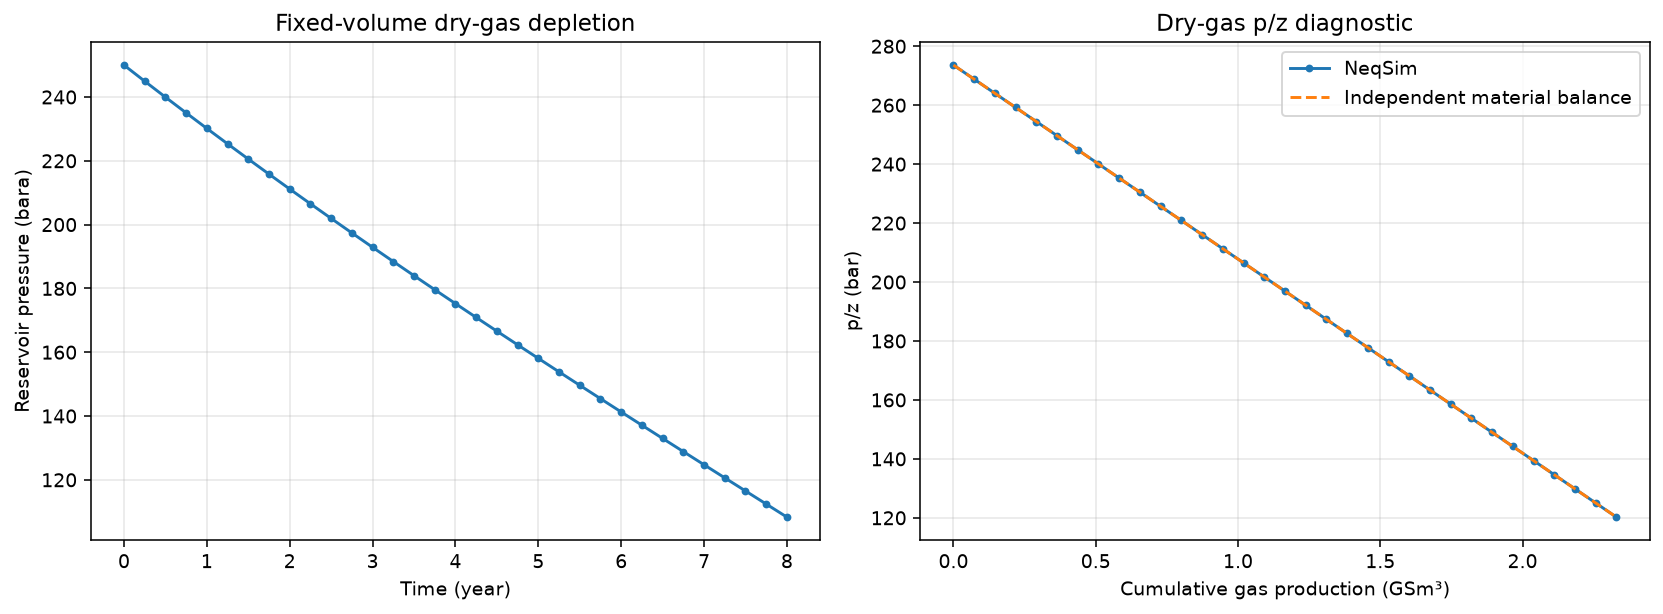

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    base_results["year"],
    base_results["pressure_bara"],
    marker="o",
    markersize=3,
    label="NeqSim pressure",
)
axes[0].set_xlabel("Time (year)")
axes[0].set_ylabel("Reservoir pressure (bara)")
axes[0].set_title("Fixed-volume dry-gas depletion")
axes[0].grid(alpha=0.3)

cumulative_gas_gsm3 = (
    base_results["cumulative_production_sm3"] / 1.0e9
)
axes[1].plot(
    cumulative_gas_gsm3,
    base_results["p_over_z_bara"],
    marker="o",
    markersize=3,
    label="NeqSim",
)
axes[1].plot(
    cumulative_gas_gsm3,
    base_results["predicted_p_over_z_bara"],
    linestyle="--",
    label="Independent material balance",
)
axes[1].set_xlabel("Cumulative gas production (GSm³)")
axes[1].set_ylabel("p/z (bar)")
axes[1].set_title("Dry-gas p/z diagnostic")
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()
plt.show()

## 13. Gas-reinjection scenario

Reinjecting 40% of the scheduled gas rate reduces net voidage and therefore supports pressure.
The scenario uses a distinct `SimpleReservoir` object and an explicit injector stream. Because
the injected fluid is identical to the reservoir gas, the comparison isolates inventory support.

This is not a compression or economics study. Injection pressure, compressor power, well
injectivity, recycling losses, and sales-gas opportunity cost are excluded.

In [13]:
reinjection_fraction = 0.40
reinjection_reservoir, reinjection_results, _ = simulate_depletion(
    production_rate_msm3_per_day,
    reinjection_fraction=reinjection_fraction,
    years=8.0,
    steps_per_year=4,
)

scenario_summary = pd.DataFrame(
    {
        "Scenario": ["Depletion", "40% gas reinjection"],
        "Final pressure (bara)": [
            base_results["pressure_bara"].iloc[-1],
            reinjection_results["pressure_bara"].iloc[-1],
        ],
        "Gross production (GSm³)": [
            base_results["cumulative_production_sm3"].iloc[-1] / 1.0e9,
            reinjection_results["cumulative_production_sm3"].iloc[-1] / 1.0e9,
        ],
        "Net withdrawal (GSm³)": [
            base_results["net_withdrawal_sm3"].iloc[-1] / 1.0e9,
            reinjection_results["net_withdrawal_sm3"].iloc[-1] / 1.0e9,
        ],
        "Maximum relative mole residual": [
            base_results["relative_mole_residual"].max(),
            reinjection_results["relative_mole_residual"].max(),
        ],
    }
)
display(scenario_summary)

              Scenario  Final pressure (bara)  Gross production (GSm³)  Net withdrawal (GSm³)  Maximum relative mole residual
0            Depletion             108.304741                 2.329935               2.329935                    9.705193e-10
1  40% gas reinjection             161.469311                 2.329935               1.394891                    3.008610e-08


## 14. Production-rate sensitivity

Three constant-rate schedules show the depletion trade-off over the same eight-year horizon.
This is a scenario study, not a well-deliverability calculation: every rate is imposed even as
pressure declines. A real forecast would couple the reservoir to tubing, gathering, compression,
sales constraints, and minimum bottom-hole pressure.

In [14]:
rate_cases_msm3_day = [0.5, 0.8, 1.1]
rate_frames = {}
rate_rows = []

for rate_msm3_day in rate_cases_msm3_day:
    _, rate_results, rate_initial_gip_sm3 = simulate_depletion(
        rate_msm3_day,
        years=8.0,
        steps_per_year=1,
    )
    rate_frames[rate_msm3_day] = rate_results
    rate_rows.append(
        {
            "Production rate (MSm³/day)": rate_msm3_day,
            "Final pressure (bara)": rate_results["pressure_bara"].iloc[-1],
            "Eight-year production (GSm³)": (
                rate_results["cumulative_production_sm3"].iloc[-1] / 1.0e9
            ),
            "Recovery fraction": (
                rate_results["cumulative_production_sm3"].iloc[-1]
                / rate_initial_gip_sm3
            ),
            "Minimum phase count": int(rate_results["phase_count"].min()),
        }
    )

rate_summary = pd.DataFrame(rate_rows)
display(rate_summary)

   Production rate (MSm³/day)  Final pressure (bara)  Eight-year production (GSm³)  Recovery fraction  Minimum phase count
0                         0.5             158.069235                      1.456209           0.350344                    1
1                         0.8             108.304741                      2.329935           0.560550                    1
2                         1.1              58.580150                      3.203661           0.770757                    1


## 15. Scenario visualization and engineering reading

Higher production rate gives more cumulative gas but leaves less pressure after eight years.
Reinjection shifts the pressure curve upward at the same gross production rate. These trends are
the expected inventory response of a closed tank; they are not evidence that the chosen schedule
is operationally or economically optimal.

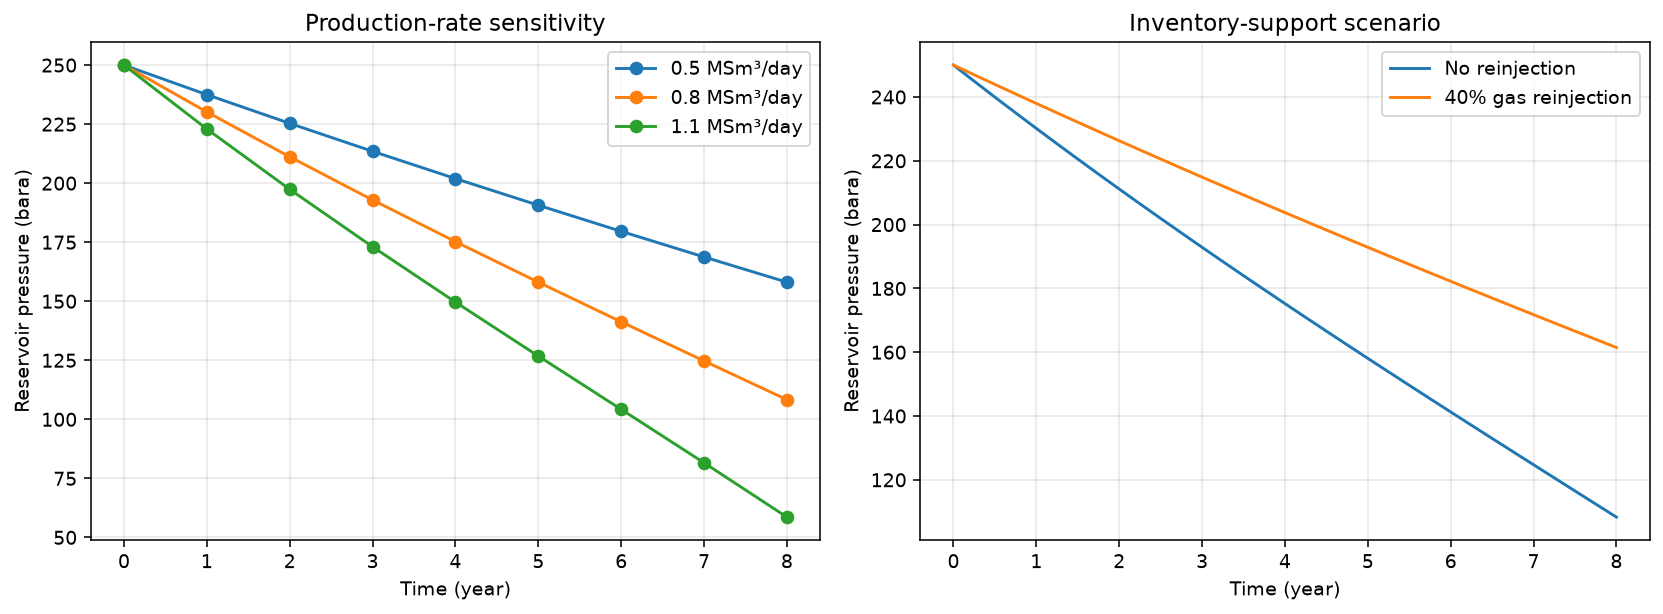

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for rate_msm3_day, rate_results in rate_frames.items():
    axes[0].plot(
        rate_results["year"],
        rate_results["pressure_bara"],
        marker="o",
        label=f"{rate_msm3_day:.1f} MSm³/day",
    )

axes[0].set_xlabel("Time (year)")
axes[0].set_ylabel("Reservoir pressure (bara)")
axes[0].set_title("Production-rate sensitivity")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    base_results["year"],
    base_results["pressure_bara"],
    label="No reinjection",
)
axes[1].plot(
    reinjection_results["year"],
    reinjection_results["pressure_bara"],
    label="40% gas reinjection",
)
axes[1].set_xlabel("Time (year)")
axes[1].set_ylabel("Reservoir pressure (bara)")
axes[1].set_title("Inventory-support scenario")
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()
plt.show()

## 16. Validation, limitations, and troubleshooting

The checks below require finite states, a single gas phase, monotonic depletion, material
closure, agreement with the independent $p/z$ equation, and the expected ordering of scenario
pressures. Failure is intentional and diagnostic rather than silently producing a plot.

If a TV flash fails, reduce the time step and confirm that a step does not withdraw more moles
than remain. If a liquid phase appears, replace the dry-gas $p/z$ check with a compositional
phase/material balance. If pressure approaches the low-pressure limit, stop the schedule or
couple a deliverability model. For field work, tune the EOS to laboratory PVT data and add
spatial reservoir simulation, wells, aquifer behavior, rock compressibility, and facilities.

In [16]:
validation_checks = {
    "normalized composition": math.isclose(
        composition_total,
        1.0,
        rel_tol=0.0,
        abs_tol=1.0e-12,
    ),
    "finite base results": bool(
        np.isfinite(
            base_results[
                ["pressure_bara", "z_factor", "gas_in_place_sm3"]
            ].to_numpy()
        ).all()
    ),
    "single gas phase": bool((base_results["phase_count"] == 1).all()),
    "monotonic pressure decline": bool(
        (base_results["pressure_bara"].diff().dropna() < 0.0).all()
    ),
    "monotonic cumulative production": bool(
        (
            base_results["cumulative_production_sm3"]
            .diff()
            .dropna()
            > 0.0
        ).all()
    ),
    "base standard-volume closure": maximum_standard_residual_sm3 < 10.0,
    "base mole closure": maximum_relative_mole_residual < 1.0e-8,
    "p/z material-balance agreement": (
        maximum_relative_p_over_z_difference < 1.0e-7
    ),
    "pressure remains positive": bool(
        (base_results["pressure_bara"] > 1.0).all()
    ),
    "reinjection supports pressure": bool(
        reinjection_results["pressure_bara"].iloc[-1]
        > base_results["pressure_bara"].iloc[-1]
    ),
    "reinjection mole closure": bool(
        reinjection_results["relative_mole_residual"].max() < 1.0e-7
    ),
    "rate sensitivity ordered": bool(
        rate_summary["Final pressure (bara)"].is_monotonic_decreasing
    ),
}

for check_name, passed in validation_checks.items():
    assert passed, f"Validation failed: {check_name}"

final_summary = pd.DataFrame(
    {
        "Metric": [
            "Initial gas in place",
            "Base final pressure",
            "Base eight-year recovery",
            "Reinjection final pressure",
            "Maximum standard-volume residual",
            "Maximum relative mole residual",
            "Maximum relative p/z difference",
            "Engineering checks passed",
        ],
        "Value": [
            base_initial_gip_sm3 / 1.0e9,
            base_results["pressure_bara"].iloc[-1],
            base_results["recovery_fraction"].iloc[-1],
            reinjection_results["pressure_bara"].iloc[-1],
            maximum_standard_residual_sm3,
            maximum_relative_mole_residual,
            maximum_relative_p_over_z_difference,
            len(validation_checks),
        ],
        "Unit": [
            "GSm³",
            "bara",
            "fraction",
            "bara",
            "Sm³",
            "fraction",
            "fraction",
            "checks",
        ],
    }
)

print(f"All {len(validation_checks)} engineering checks passed.")
display(final_summary)

All 12 engineering checks passed.
                             Metric         Value      Unit
0              Initial gas in place  4.156515e+00      GSm³
1               Base final pressure  1.083047e+02      bara
2          Base eight-year recovery  5.605502e-01  fraction
3        Reinjection final pressure  1.614693e+02      bara
4  Maximum standard-volume residual  4.065609e+00       Sm³
5    Maximum relative mole residual  9.705193e-10  fraction
6   Maximum relative p/z difference  2.227252e-09  fraction
7         Engineering checks passed  1.200000e+01    checks


## 17. Summary, references, and exercises

The notebook built an executed, compositional dry-gas tank using NeqSim's current
`SimpleReservoir` API. It demonstrated constant-volume depletion, independent $p/z$ validation,
component conservation, production-rate sensitivity, and gas-reinjection pressure support.
The main engineering conclusion is that inventory management changes the pressure trajectory,
while the tank model alone cannot determine well or facility feasibility.

### Current NeqSim references

- [Dynamic simulation guide — reservoirs and transient stepping](https://equinor.github.io/neqsim/simulation/dynamic_simulation_guide.html)
- [Thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [Thermodynamic operations and TV flashes](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [Google Colab quickstart](https://equinor.github.io/neqsim/quickstart/colab-quickstart.html)
- [SimpleReservoir source and API implementation](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/reservoir/SimpleReservoir.java)

### Exercises

1. Halve the time step and confirm the final pressure and conservation residuals are unchanged.
2. Replace Peng-Robinson with SRK and quantify changes in initial gas in place and final pressure.
3. Add a richer gas and stop using the dry-gas $p/z$ check if condensate appears.
4. Couple the producer to a tubing or pipeline model and impose a minimum delivery pressure.
5. Add an aquifer or water-injection support scenario and document the extra assumptions.